In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from fair_mast_benchmarks.dataset import load_dataset
from fair_mast_benchmarks.dataset.windows import sliding_window
from fair_mast_benchmarks.utils import binary_segments, znormalize

rc('font',**{'family':'serif','serif':['Arial Narrow']})
plt.style.use('ggplot')

dataset = load_dataset('../data/shots.nc', 'elm_peaks', split="train")
shot = dataset.isel(shot=0)

regions = binary_segments(shot["label"].values)

## Learning to label data with Shaplets

First let's start with a labelled dataset. Here we use real experimental data with ELM events labelled.

Text(0.5, 1.0, 'ELM event in Dalpha and ELM signals')

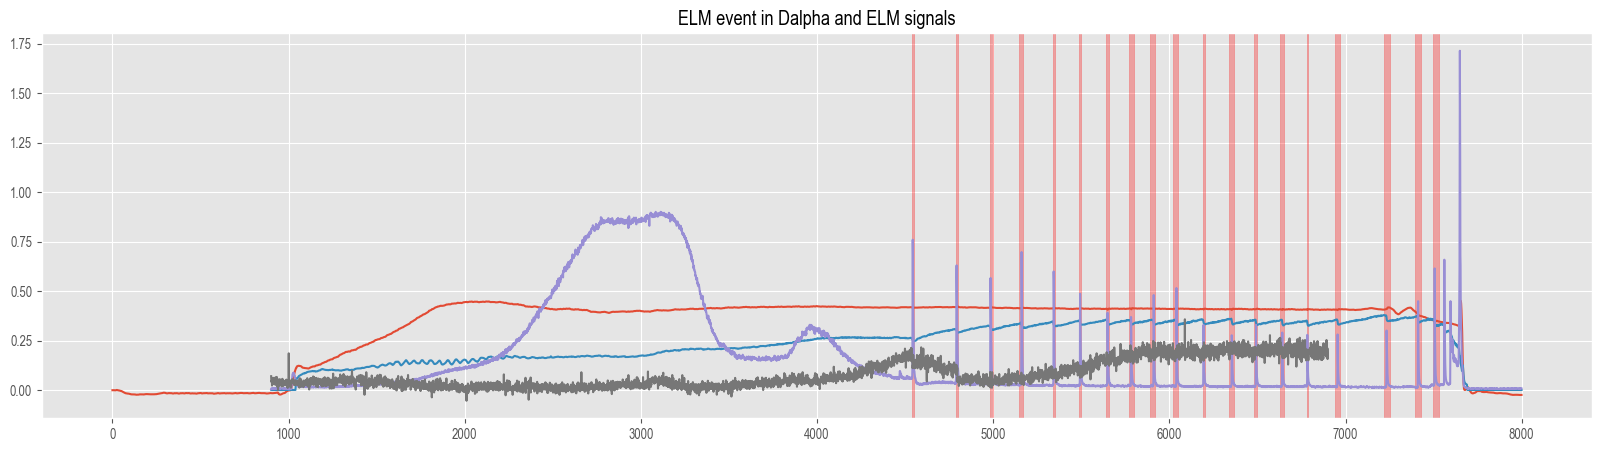

In [24]:
plt.figure(figsize=(20, 5))
plt.plot(shot.ip / 1e6)
plt.plot(shot.n_e / 1e20)
plt.plot(shot.dalpha)
plt.plot(shot.soft_x_rays*100)

for start, end in regions:
    plt.axvspan(start, end, color='red', alpha=0.3)

plt.title('ELM event in Dalpha and ELM signals')

Let's split this trace into a training and test set. We will use the annotations from the first half of the data for training and the second half for testing.

Text(0.5, 1.0, 'Test Split')

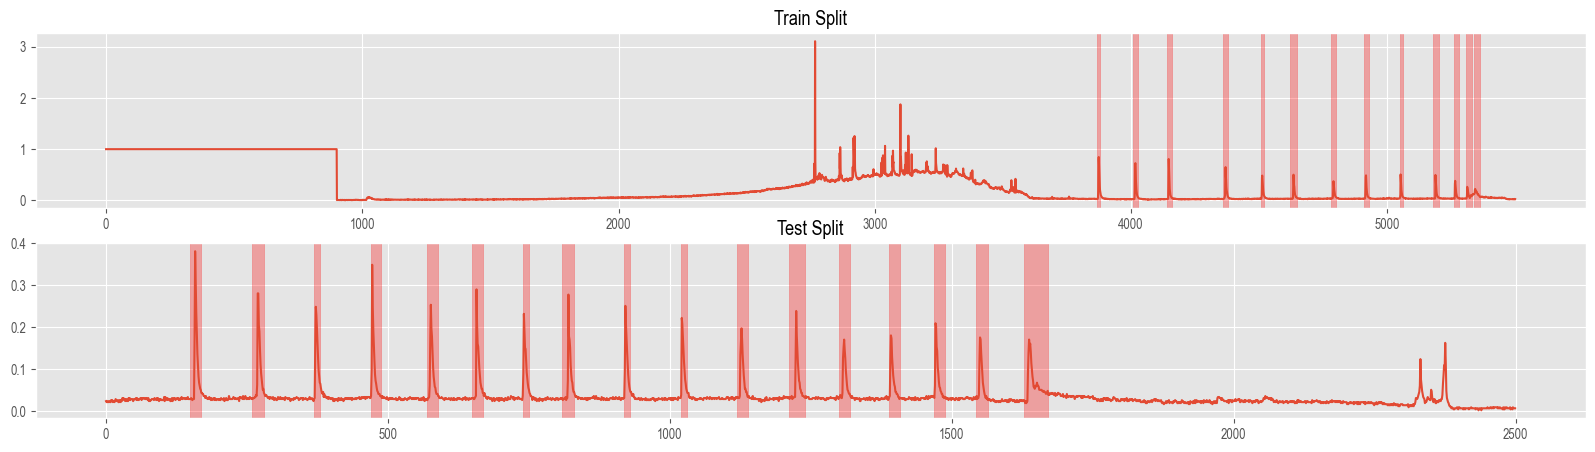

In [13]:
idx = 5500
trace = data[:, -1]

x_train = trace[:idx]
x_test = trace[idx:]
y_train = label[:idx]
y_test = label[idx:]

train_regions = binary_segments(y_train)
test_regions = binary_segments(y_test)

fig, axes = plt.subplots(2, 1, figsize=(20, 5))

axes[0].plot(x_train, label='Train')
for start, end in train_regions:
    axes[0].axvspan(start, end, color='red', alpha=0.3)
axes[1].plot(x_test, label='Test')

for start, end in test_regions:
    axes[1].axvspan(start, end, color='red', alpha=0.3)
axes[0].set_title('Train Split')
axes[1].set_title('Test Split')

We can use the labelled regions to define shaplets for training a clasaifier

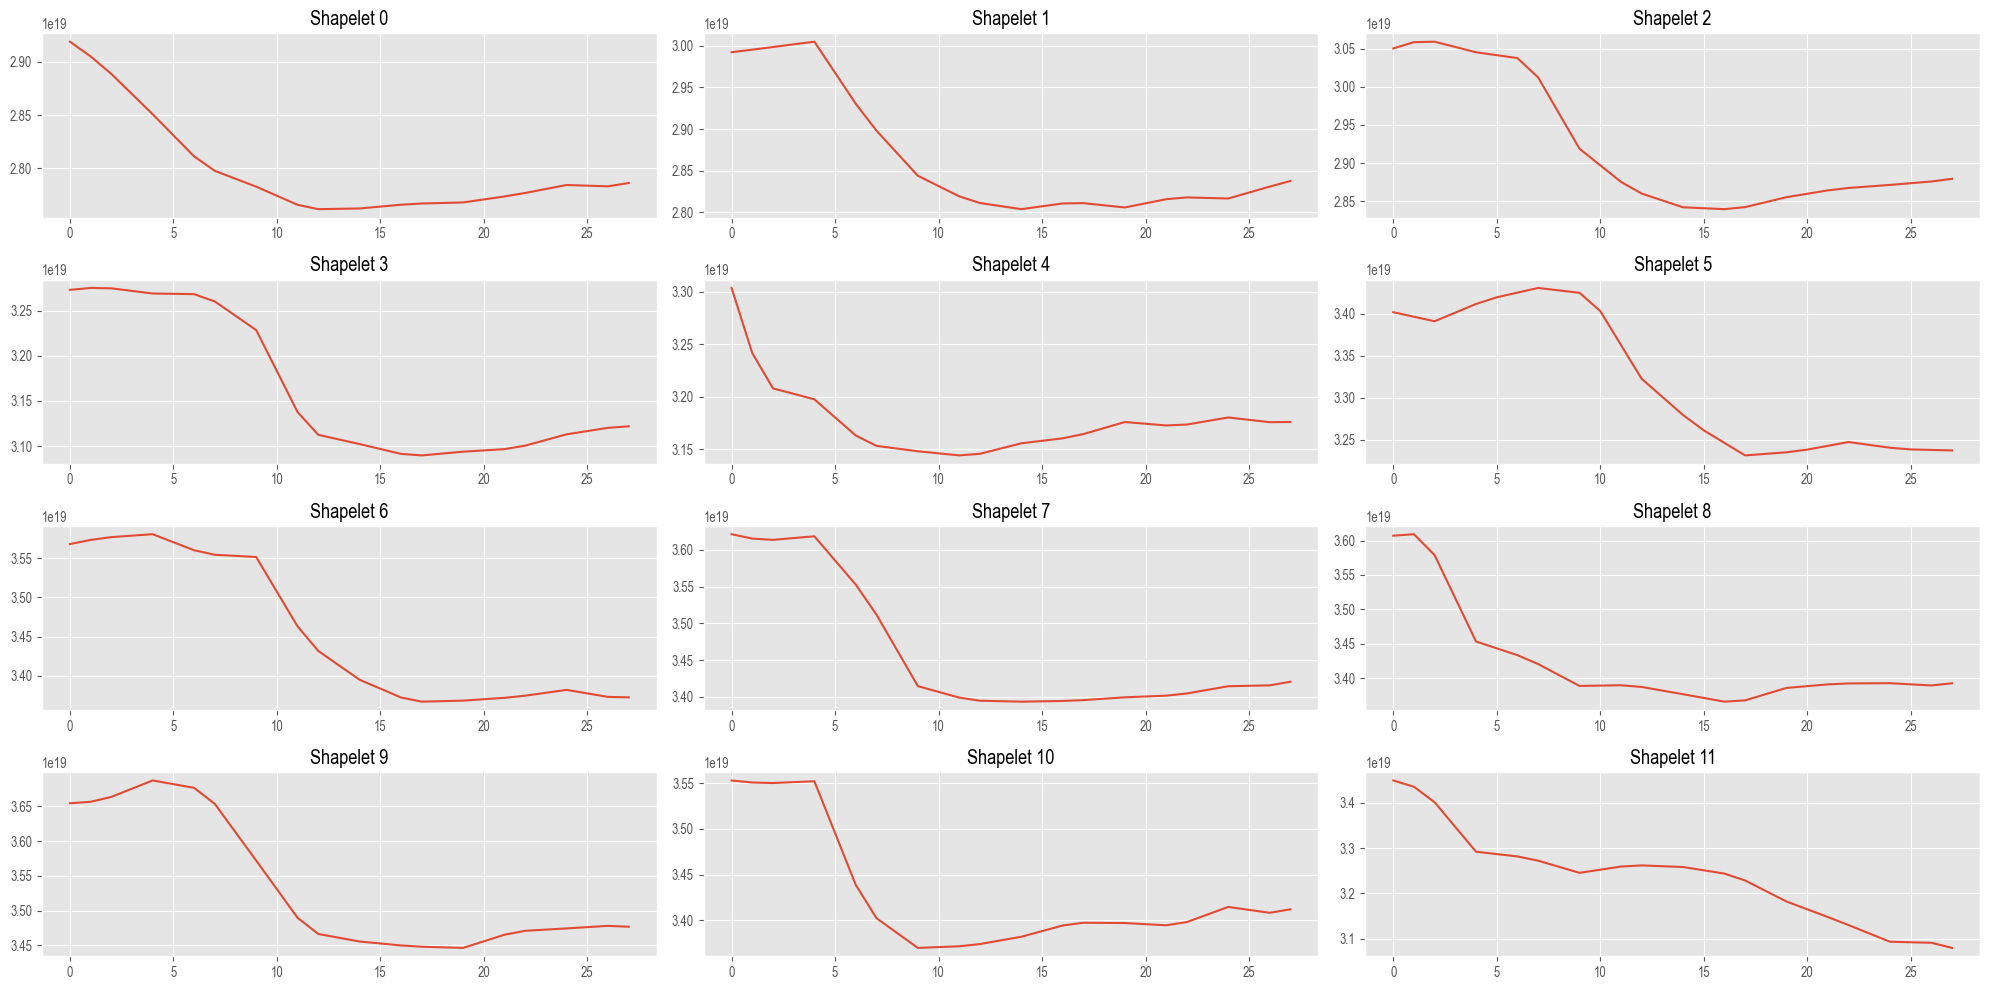

In [49]:
def select_shapelet(data, region, max_len, padding: int = 0):
    imin, imax = region
    shapelet = data[imin-padding:imin+max_len+padding]
    return shapelet

max_len = max(end - start for start, end in train_regions)
shaplets = np.array([select_shapelet(trace, region, max_len) for region in train_regions])

fig, axes = plt.subplots(figsize=(20, 10), nrows=len(shaplets) // 3, ncols=3)
for i, (ax, shapelet) in enumerate(zip(axes.flatten(), shaplets)):
    plt.subplot(len(shaplets) // 3, 3, i + 1)
    plt.plot(shapelet)
    plt.title(f'Shapelet {i}')
plt.tight_layout()


Now compute the shapelet transform

              precision    recall  f1-score   support

           0       0.80      0.95      0.87      1663
           1       0.82      0.51      0.63       810

    accuracy                           0.80      2473
   macro avg       0.81      0.73      0.75      2473
weighted avg       0.80      0.80      0.79      2473



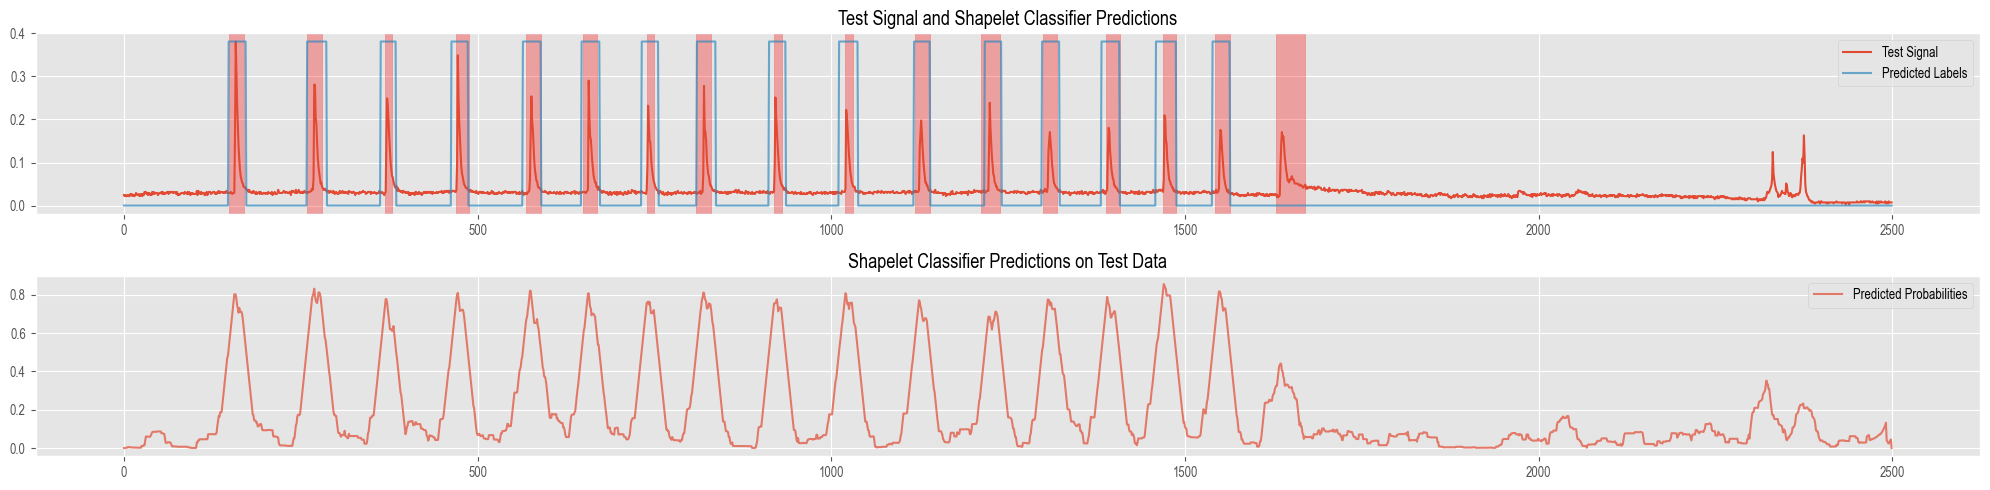

In [16]:
from aeon.distances import dtw_distance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

class ShapeletTransform:
    def __init__(self, shapelets, distance_metric='norm'):
        self.shapelets = shapelets
        self.distance_metric = distance_metric
        
        if distance_metric == 'dtw':
            self.distance_func = dtw_distance
        else:
            self.distance_func= self.euclidean_distance

    def euclidean_distance(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2))

    def transform(self, X):
        features = []
        for shapelet in self.shapelets:
            shapelet_znorm = znormalize(shapelet)
            windows_znorm = np.array([znormalize(window) for window in X])
            distances = np.array([dtw_distance(window, shapelet_znorm) for window in windows_znorm])
            features.append(distances)
            
        return np.array(features).T

window_size = max_len
step_size = 1

x_train_windows = sliding_window(x_train, window_size, step_size)
x_test_windows = sliding_window(x_test, window_size, step_size)
y_train_windows = sliding_window(y_train, window_size, step_size).max(axis=1)
y_test_windows = sliding_window(y_test, window_size, step_size).max(axis=1)

transformer = ShapeletTransform(shaplets[:1])
x_train_features = transformer.transform(x_train_windows)
x_test_features = transformer.transform(x_test_windows)


clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train_features, y_train_windows)
y_pred = clf.predict(x_test_features)
y_probs = clf.predict_proba(x_test_features)
y_probs = y_probs[:, 1]

print(classification_report(y_test_windows, y_pred))

def windows_to_time_majority(window_labels, T, window_size, stride):
    votes = np.zeros(T)
    counts = np.zeros(T)

    for i, wl in enumerate(window_labels):
        # delta = window_size // 2
        start = max(i * stride, 0)
        end = min(start + window_size, T)
        votes[start:end] += wl
        counts[start:end] += 1

    return votes / counts

probs = windows_to_time_majority(y_probs, y_test.shape[0], shapelet.shape[0], 1)
labels = (probs > 0.5).astype(int)

fig, axes = plt.subplots(2, 1, figsize=(20, 5))
axes[0].plot(x_test, label='Test Signal')
axes[0].plot(labels * np.max(x_test), label='Predicted Labels', alpha=0.7)
axes[1].plot(probs, label='Predicted Probabilities', alpha=0.7)
axes[0].set_title('Test Signal and Shapelet Classifier Predictions')
for start, end in test_regions:
    axes[0].axvspan(start, end, color='red', alpha=0.3)
axes[1].set_title('Shapelet Classifier Predictions on Test Data')
axes[0].legend()
axes[1].legend()
plt.tight_layout()

Now try with the density signal

Text(0.5, 1.0, 'Test Split')

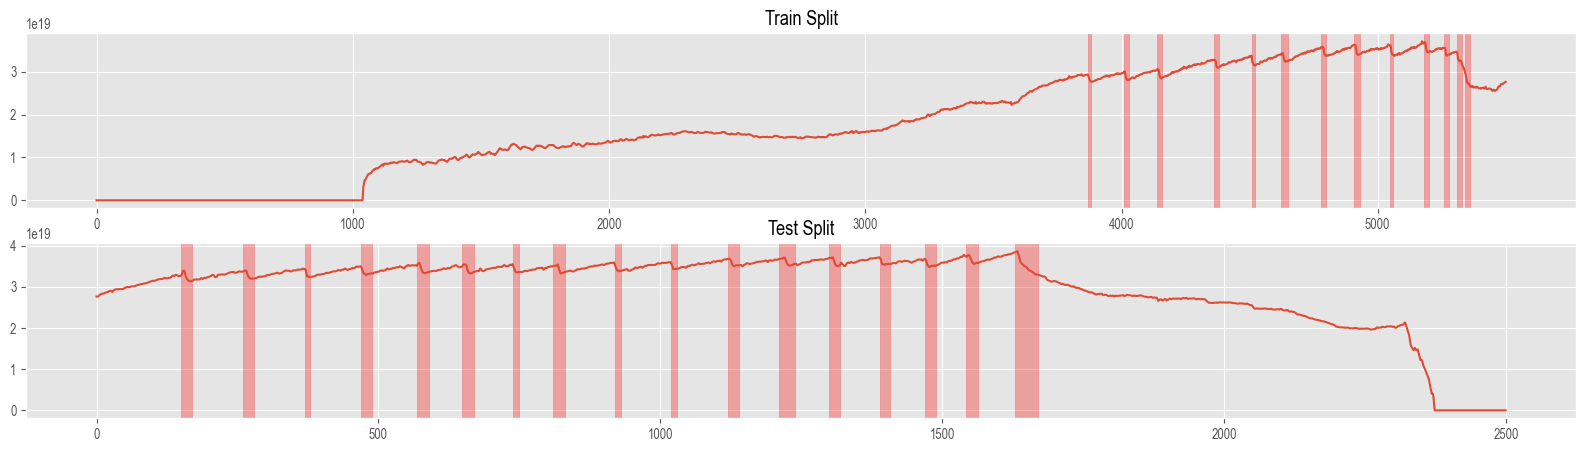

In [60]:
idx = 5500
trace = data[:, 1]

x_train = trace[:idx]
x_test = trace[idx:]
y_train = label[:idx]
y_test = label[idx:]

train_regions = binary_segments(y_train)
test_regions = binary_segments(y_test)

fig, axes = plt.subplots(2, 1, figsize=(20, 5))

axes[0].plot(x_train, label='Train')
for start, end in train_regions:
    axes[0].axvspan(start, end, color='red', alpha=0.3)
axes[1].plot(x_test, label='Test')

for start, end in test_regions:
    axes[1].axvspan(start, end, color='red', alpha=0.3)
axes[0].set_title('Train Split')
axes[1].set_title('Test Split')

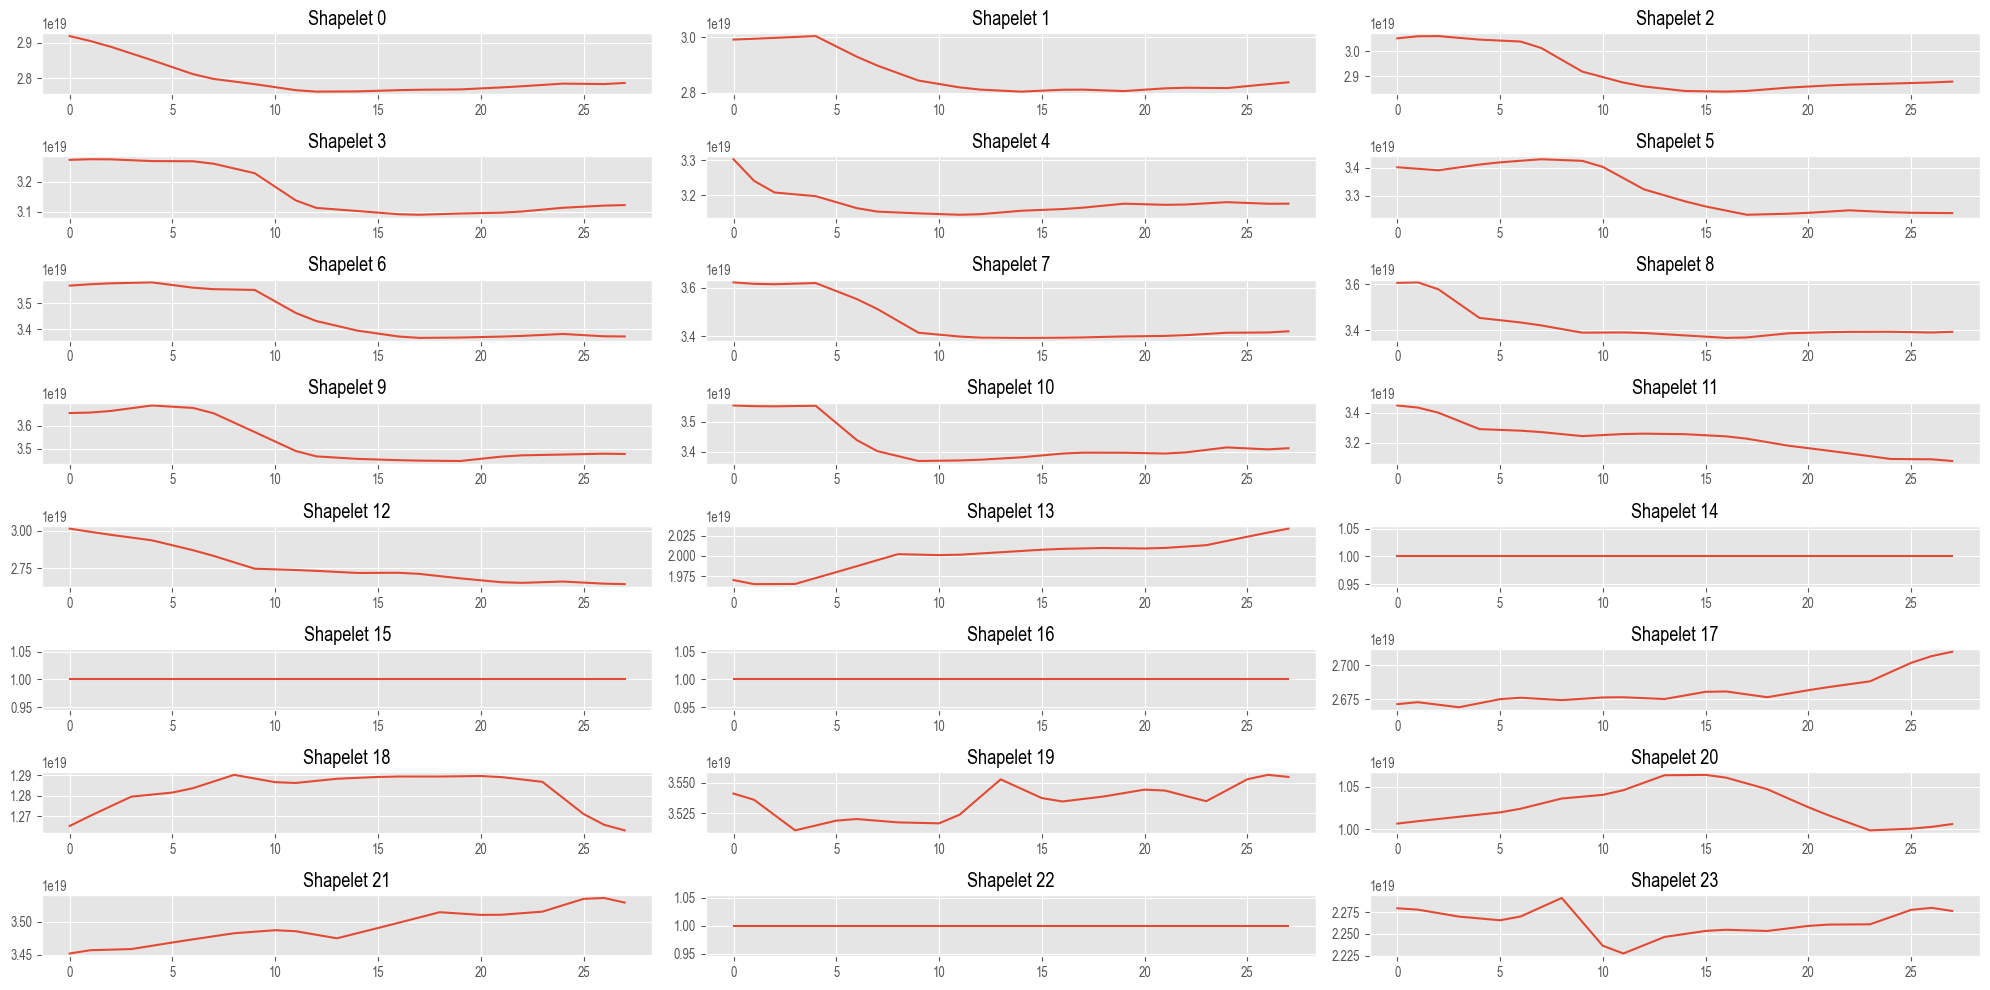

In [192]:
max_len = max(end - start for start, end in train_regions)
padding = 0
shaplets = np.array([select_shapelet(trace, region, max_len, padding=padding) for region in train_regions])

window_size = max_len + padding * 2
step_size = 10

x_train_windows = sliding_window(x_train, window_size, step_size)
x_test_windows = sliding_window(x_test, window_size, step_size)
y_train_windows = sliding_window(y_train, window_size, step_size).max(axis=1)
y_test_windows = sliding_window(y_test, window_size, step_size).max(axis=1)

negative_windows = x_train_windows[y_train_windows == 0]
negative_indices = np.random.choice(len(negative_windows), size=len(shaplets), replace=False)
negative_shaplets = negative_windows[negative_indices]
shaplets = np.concatenate([shaplets, negative_shaplets], axis=0)

fig, axes = plt.subplots(figsize=(20, 10), nrows=len(shaplets) // 3, ncols=3)
for i, (ax, shapelet) in enumerate(zip(axes.flatten(), shaplets)):
    plt.subplot(len(shaplets) // 3, 3, i + 1)
    plt.plot(shapelet)
    plt.title(f'Shapelet {i}')
plt.tight_layout()

              precision    recall  f1-score   support

           0       0.89      0.90      0.89       174
           1       0.75      0.73      0.74        74

    accuracy                           0.85       248
   macro avg       0.82      0.81      0.82       248
weighted avg       0.85      0.85      0.85       248



/var/folders/xr/yr8z575s52b4tbg3fj65qwx00000gp/T/ipykernel_96722/3265397321.py:18: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew = scipy.stats.skew(znormalized_X, axis=1, keepdims=True)
/var/folders/xr/yr8z575s52b4tbg3fj65qwx00000gp/T/ipykernel_96722/3265397321.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis = scipy.stats.kurtosis(znormalized_X, axis=1, keepdims=True)
/var/folders/xr/yr8z575s52b4tbg3fj65qwx00000gp/T/ipykernel_96722/353997095.py:60: RuntimeWarning: invalid value encountered in divide
  return votes / counts


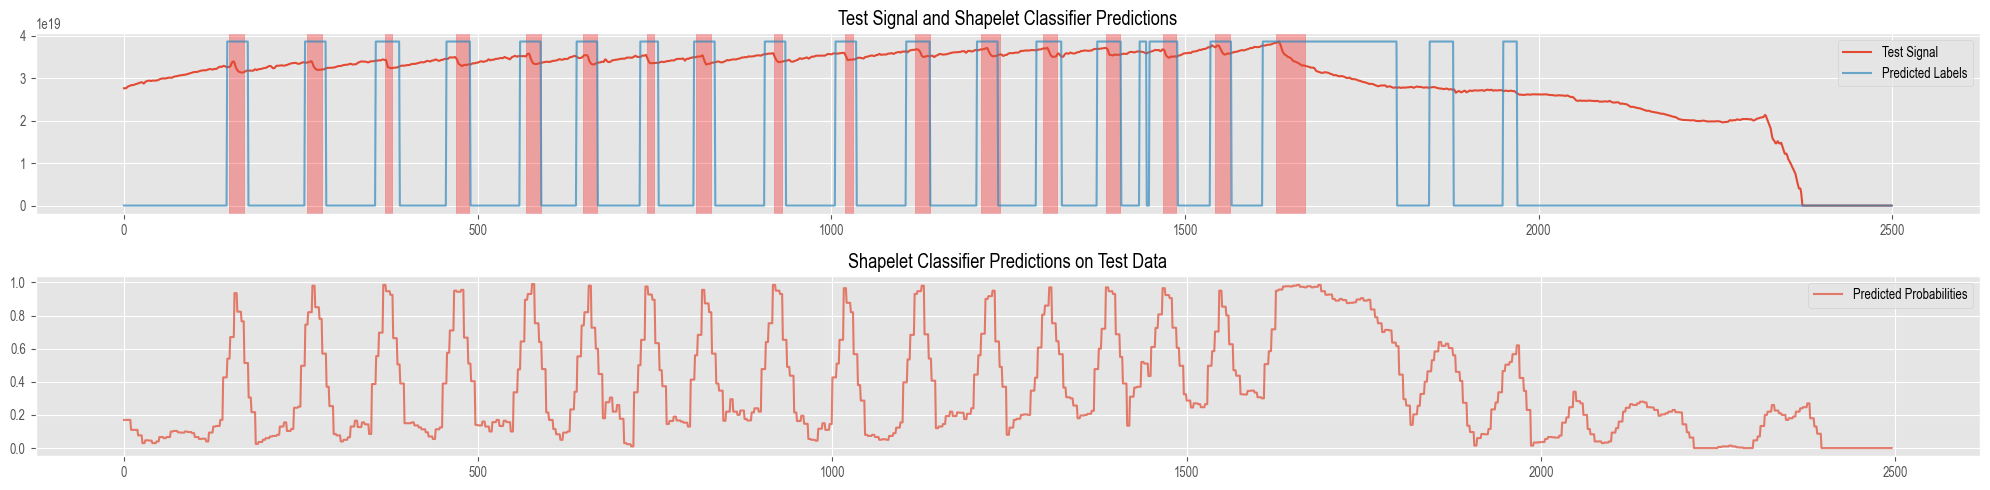

In [193]:
import scipy.stats

class FeatureTransformer:
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.mean_ = np.mean(X)
        self.std_ = np.std(X)
    
    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X)
    
    def transform(self, X):
        znormalized_X = (X - self.mean_) / self.std_

        skew = scipy.stats.skew(znormalized_X, axis=1, keepdims=True)
        skew = np.nan_to_num(skew, nan=0.0)

        kurtosis = scipy.stats.kurtosis(znormalized_X, axis=1, keepdims=True)
        kurtosis = np.nan_to_num(kurtosis, nan=0.0)

        slopes, intercepts = self._poly_fit(znormalized_X)
        return np.concatenate([
            np.mean(znormalized_X, axis=1, keepdims=True),
            np.std(znormalized_X, axis=1, keepdims=True),
            np.max(znormalized_X, axis=1, keepdims=True),
            np.min(znormalized_X, axis=1, keepdims=True),
            skew,
            kurtosis,
            slopes[:, np.newaxis],
            intercepts[:, np.newaxis],
            np.sum(znormalized_X ** 2, axis=1, keepdims=True)
        ], axis=1)

    def _poly_fit(self, X):
        slopes = []
        intercepts = []
        for x in X:
            slope, intercept = np.polyfit(np.arange(len(x)), x, 1)
            slopes.append(slope)
            intercepts.append(intercept)

        return np.array(slopes), np.array(intercepts)
        

transformer = ShapeletTransform(shaplets)
x_train_features = transformer.transform(x_train_windows)
x_test_features = transformer.transform(x_test_windows)

ft = FeatureTransformer()
x_train_features = np.concatenate((x_train_features, ft.fit_transform(x_train_windows)), axis=1)
x_test_features = np.concatenate((x_test_features, ft.transform(x_test_windows)), axis=1)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
from sklearn.linear_model import LogisticRegression
# clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(x_train_features, y_train_windows)

y_pred = clf.predict(x_test_features)
y_probs = clf.predict_proba(x_test_features)
y_probs = y_probs[:, 1]

print(classification_report(y_test_windows, y_pred))

probs = windows_to_time_majority(y_probs, y_test.shape[0], shaplets.shape[0], step_size)
labels = (probs > 0.5).astype(int)

fig, axes = plt.subplots(2, 1, figsize=(20, 5))
axes[0].plot(x_test, label='Test Signal')
axes[0].plot(labels * np.max(x_test), label='Predicted Labels', alpha=0.7)
axes[1].plot(probs, label='Predicted Probabilities', alpha=0.7)
axes[0].set_title('Test Signal and Shapelet Classifier Predictions')
for start, end in test_regions:
    axes[0].axvspan(start, end, color='red', alpha=0.3)
axes[1].set_title('Shapelet Classifier Predictions on Test Data')
axes[0].legend()
axes[1].legend()
plt.tight_layout()

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       659
           1       0.83      0.76      0.79       139

    accuracy                           0.93       798
   macro avg       0.89      0.86      0.88       798
weighted avg       0.93      0.93      0.93       798



/var/folders/xr/yr8z575s52b4tbg3fj65qwx00000gp/T/ipykernel_96722/3265397321.py:18: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew = scipy.stats.skew(znormalized_X, axis=1, keepdims=True)
/var/folders/xr/yr8z575s52b4tbg3fj65qwx00000gp/T/ipykernel_96722/3265397321.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis = scipy.stats.kurtosis(znormalized_X, axis=1, keepdims=True)
/var/folders/xr/yr8z575s52b4tbg3fj65qwx00000gp/T/ipykernel_96722/353997095.py:60: RuntimeWarning: invalid value encountered in divide
  return votes / counts


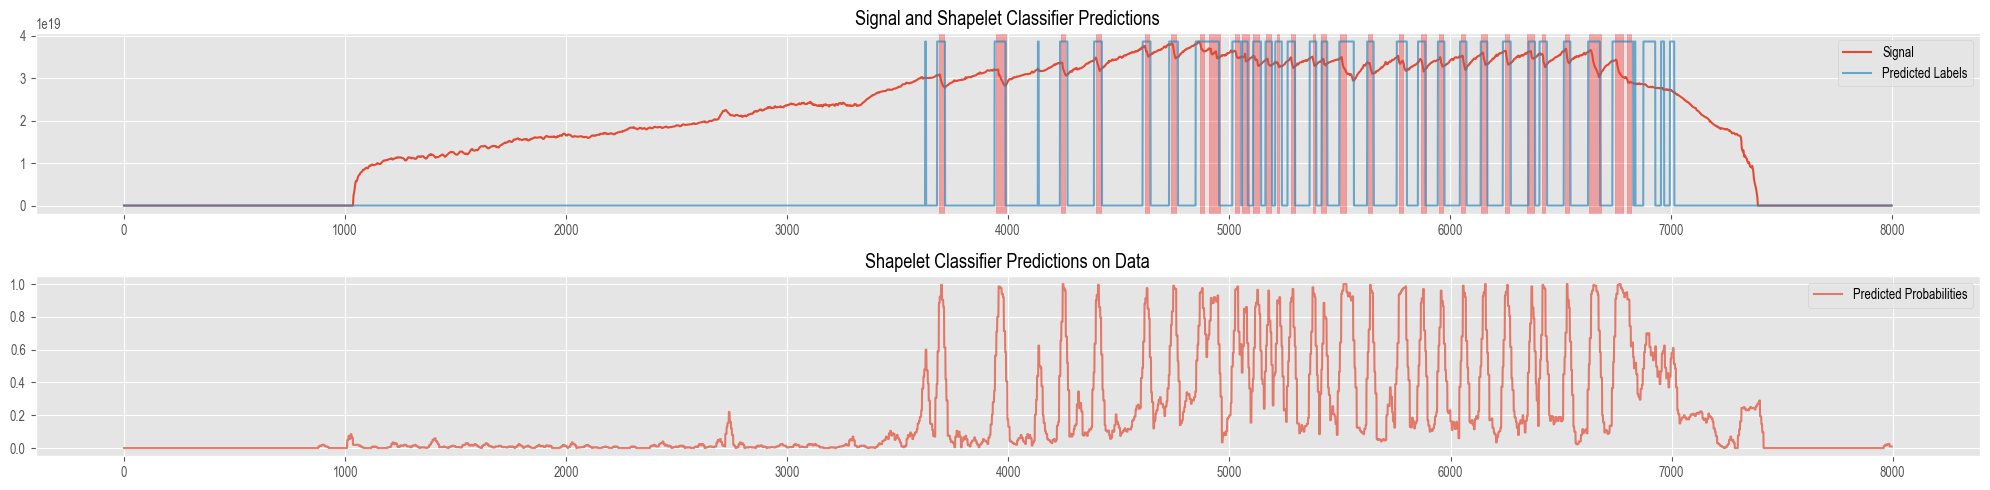

In [164]:
sample2 = dataset['train'][-3]
data2 = np.stack(sample2['data'])
label2 = np.array(sample2['label']).squeeze()

trace2 = data2[:, 1]

x_windows = sliding_window(trace2, window_size, step_size)
x_windows_features = transformer.transform(x_windows)
x_windows_features = np.concatenate((x_windows_features, ft.transform(x_windows)), axis=1)
y_windows = sliding_window(label2, window_size, step_size).max(axis=1)

y_pred = clf.predict(x_windows_features)
y_probs = clf.predict_proba(x_windows_features)
y_probs = y_probs[:, 1]
print(classification_report(y_windows, y_pred))

probs = windows_to_time_majority(y_probs, label2.shape[0], shaplets.shape[0], step_size)
labels = (probs > 0.5).astype(int)
fig, axes = plt.subplots(2, 1, figsize=(20, 5))
axes[0].plot(trace2, label='Signal')
axes[0].plot(labels * np.max(trace2), label='Predicted Labels', alpha=0.7)
axes[1].plot(probs, label='Predicted Probabilities', alpha=0.7)
axes[0].set_title('Signal and Shapelet Classifier Predictions')
for start, end in binary_segments(label2):
    axes[0].axvspan(start, end, color='red', alpha=0.3)
axes[1].set_title('Shapelet Classifier Predictions on Data')
axes[0].legend()
axes[1].legend()
plt.tight_layout()

TODO:
 - Try predicting from one shot to another shot, assuming we have labels for the first shot
 - Try with different classifiers
 - Try with different features 
   - e.g. add trend, higher order moments, frequency domain features, wavelet features, rocket.
 - Try multi-variate shapelets
 - Try with different shapelet selection methods

              precision    recall  f1-score   support

           0       0.71      0.99      0.83       174
           1       0.71      0.07      0.12        74

    accuracy                           0.71       248
   macro avg       0.71      0.53      0.48       248
weighted avg       0.71      0.71      0.62       248



/var/folders/xr/yr8z575s52b4tbg3fj65qwx00000gp/T/ipykernel_96722/353997095.py:60: RuntimeWarning: invalid value encountered in divide
  return votes / counts


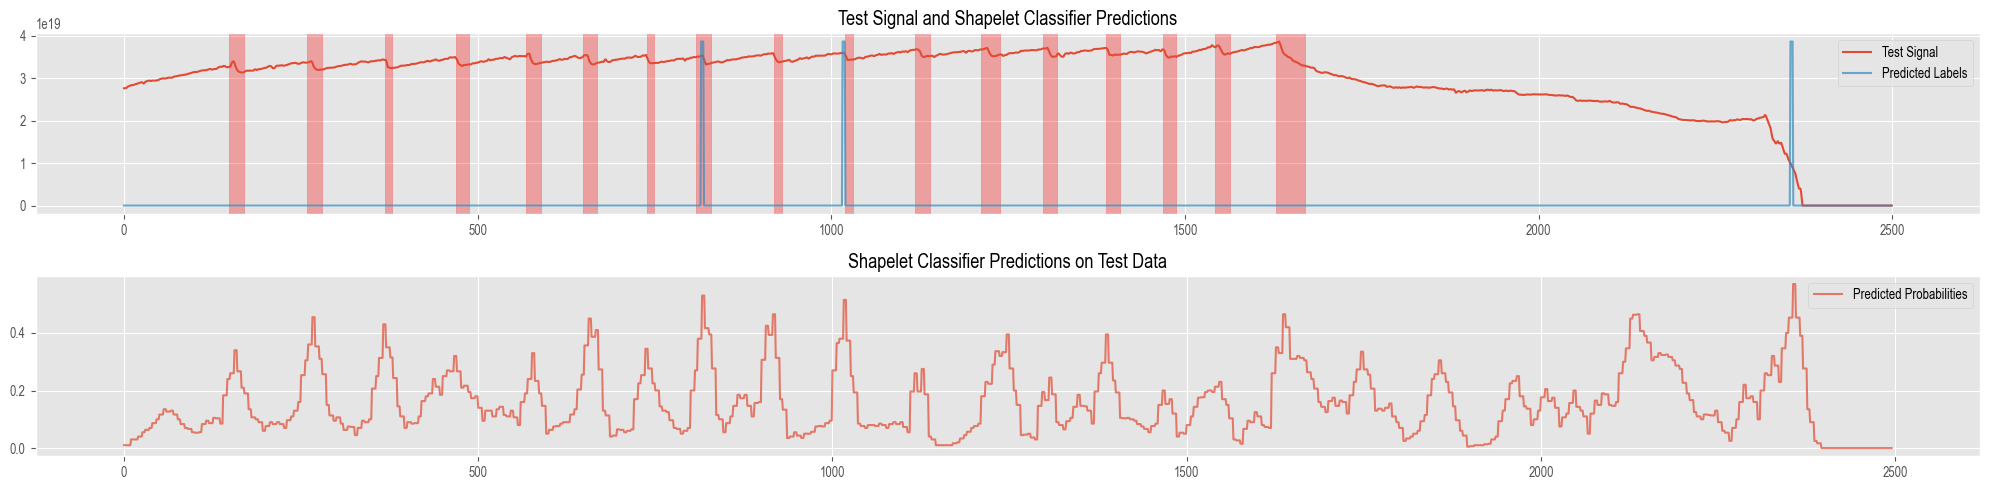

In [198]:
from aeon.classification.shapelet_based import SASTClassifier

stc = SASTClassifier(classifier=RandomForestClassifier(ccp_alpha=0.001))
stc.fit(x_train_windows, y_train_windows)


y_probs = stc.predict_proba(x_test_windows)
y_probs = y_probs[:, 1]
y_pred = (y_probs > 0.5).astype(int)

print(classification_report(y_test_windows, y_pred))

probs = windows_to_time_majority(y_probs, y_test.shape[0], shaplets.shape[0], step_size)
labels = (probs > 0.5).astype(int)

fig, axes = plt.subplots(2, 1, figsize=(20, 5))
axes[0].plot(x_test, label='Test Signal')
axes[0].plot(labels * np.max(x_test), label='Predicted Labels', alpha=0.7)
axes[1].plot(probs, label='Predicted Probabilities', alpha=0.7)
axes[0].set_title('Test Signal and Shapelet Classifier Predictions')
for start, end in test_regions:
    axes[0].axvspan(start, end, color='red', alpha=0.3)
axes[1].set_title('Shapelet Classifier Predictions on Test Data')
axes[0].legend()
axes[1].legend()
plt.tight_layout()

## Multi-channel extension with IREs

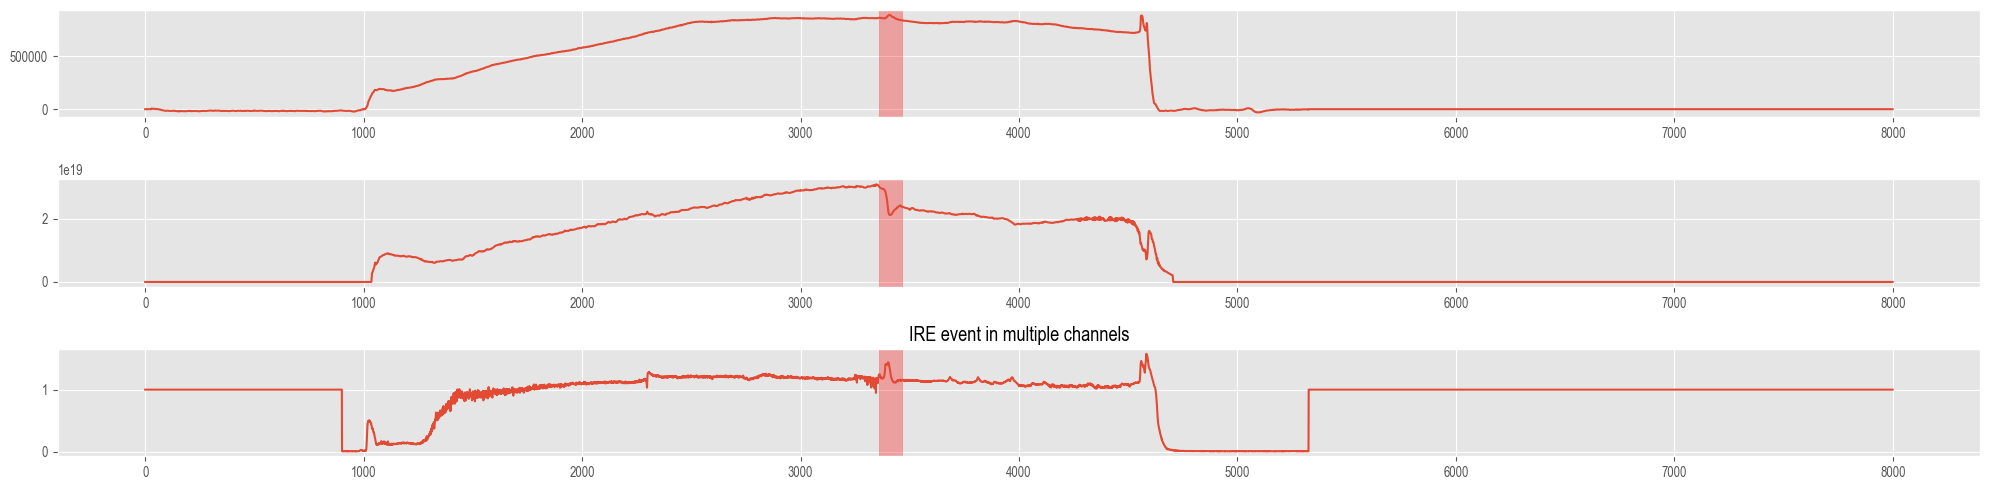

In [205]:
dataset = load_dataset(config_name='ire')
sample = dataset['train'][2]
data = np.stack(sample['data'])
label = np.array(sample['label']).squeeze()

regions = binary_segments(label)

fig, axes = plt.subplots(3, 1, figsize=(20, 5))
axes[0].plot(data[:, 0])
axes[1].plot(data[:, 1])
axes[2].plot(data[:, 2])
for start, end in regions:
    axes[0].axvspan(start, end, color='red', alpha=0.3)
    axes[1].axvspan(start, end, color='red', alpha=0.3)
    axes[2].axvspan(start, end, color='red', alpha=0.3)
plt.title('IRE event in multiple channels')
plt.tight_layout()